### Stanford eTBS preprocessing pipeline
Processes raw EDF files by:
- rereferencing (bipolar)
- filtering and resampling
- identifying stimulation trains/CCEPs/rest periods
- epoching around CCEPs
- saving as an MNE-readable .fif file

**Import necessary dependencies**

In [1]:
import mne
import numpy as np
import pandas as pd
import pylab as plt
import os
import sys
from glob import glob

sys.path.insert(0, '../lib/')  # add path to custom library

### Step-through processing a single file

**1. Import raw edf data and perform some initial formatting (e.g. cleaning channel names and assigning channel types). Code should point to a directory with the raw EDF files using a logical ordered numbering scheme.**

**NOTE: Steps 1-4 should be run for each EDF file separately, changing the line "f = fns[n]" where n is advanced to step through each file.** Files are then concatenated in Step 5 and the rest of the code runs on the one larger file. 

In [2]:
root = '../data/'
subject = 'S24_236'  # provide subject directory name, and edit file root as needed

In [3]:
from mne.io import read_raw_edf

# Identify resting-state data (this may need to be manual at times)
fns = np.sort(glob(root+subject+'/*edf'))  # need to sort as glob will not correctly order files

use_bipolar=True

# This subject had EDF files roughly split by step, meaning it is better to just loop through the files (at the expense of manual inspection)

f = fns[1]  # select the file to step through
rs = read_raw_edf(f, preload=True, encoding='latin1')

# Rename channels for convenience (remove unneccessary characters)
raw_names = rs.ch_names
new_names = [s[4:-4] for s in raw_names]
name_dict = dict(zip(raw_names, new_names))
rs.rename_channels(name_dict) 

# Reset types of stim channels, eeg channels
ch_types = {}
for ch_name in rs.ch_names:  # First set all to sEEG because this is the most common -- will re-set correctly in the next step. Handling grids/strips properly will require further modification
    ch_types[ch_name] = 'seeg' 

# Now reset remaining channels correctly
stim_triggers = ['DC01', 'DC02', 'CCEP', 'DC03', 'DC04', 'DC05', 'DC06', 'DC07', 'DC08']
eeg_names = ['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4',]
for ch_name in stim_triggers:
    if ch_name in rs.ch_names:  # not all of the above names will be in a given subject's montage
        ch_types[ch_name] = 'stim'
for ch_name in eeg_names:
    if ch_name in rs.ch_names:
        ch_types[ch_name] = 'eeg'
rs.set_channel_types(ch_types) 

Extracting EDF parameters from /Users/esolomon/scripts/Stanford_eTBS/data/S24_236/E24-1181_0160.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1791239  =      0.000 ...  1791.239 secs...


<RawEDF | E24-1181_0160.edf, 231 x 1791240 (1791.2 s), ~3.08 GiB, data loaded>

**2. Next, re-reference the data. With sEEG electrodes, we most commonly use bipolar, but common average is also available easily through MNE.**

In [4]:
# Select only sEEG for bipolar reference
seeg_struct = rs.copy().pick(picks=['seeg'])

# Bipolar re-reference
if use_bipolar:
    from codebase import construct_bipolar_montage
    an, cath = construct_bipolar_montage(seeg_struct.ch_names)
    rs = mne.set_bipolar_reference(rs, an, cath, ch_name=None, copy=True, drop_refs=True, verbose=False)
else:
    rs, _ = mne.set_eeg_reference(rs, ref_channels='average', ch_type='seeg', copy=True, verbose=False)

**3. Initial filtering step: high pass at 0.1 Hz and save outputs**

It's probably worth it to actually check in your data that HP filter is even necessary -- there are indeed sometimes slow drifts in iEEG data but this may not be universally true. We'll do it here because it is "standard."  

In [11]:
rs = rs.filter(h_freq=None, l_freq=0.1, verbose=True)

# Save outputs
try:
    os.mkdir('../preprocessed_data/'+subject+'/')
except:
    pass

# Note this may split your file into multiple subfiles due to .fif file limitations. 
# MNE knows how to load this file and does *not* need to be told about the split file specifically. 
rs.save('../preprocessed_data/'+subject+'/'+f.split('/')[-1][:-4]+'.fif', overwrite=True, verbose=False)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Filter length: 33001 samples (33.001 s)



/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_2161/2166974260.py:11: RuntimeWarning: This filename (/Users/esolomon/scripts/Stanford_eTBS/notebooks/../preprocessed_data/S24_236/E24-1181_0161.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  rs.save('../preprocessed_data/'+subject+'/'+f.split('/')[-1][:-4]+'.fif', overwrite=True, verbose=False)


[PosixPath('/Users/esolomon/scripts/Stanford_eTBS/notebooks/../preprocessed_data/S24_236/E24-1181_0161.fif')]

**4. Highly recommended: Visualize the data to check for errors or corrupted channels. MNE has tools to mark and exclude corrupted channels.**

In [6]:
rs.plot(picks='seeg', scalings='auto')

Using qt as 2D backend.
Using pyopengl with version 3.1.7


Channels marked as bad:
none


**5. Concatenate .fif files**

In [17]:
# Grab the filenames, sort, and load the data
fif_files = np.sort(glob('../preprocessed_data/'+subject+'/*fif'))

# Remove any split files -- MNE does not need to be told about these explicitly
new_fns = []
for f in fif_files:
    if '-' in f[-7:]:
        continue
    else:
        new_fns.append(f)
        
# Load the data
raws = [mne.io.read_raw_fif(f, preload=True, verbose=False) for f in new_fns]

# Concatenate - note that MNE will annotate the borders as "bad" so that the resulting file is not truly continuous. Should be OK for our purposes. 
full_sess_raw = mne.concatenate_raws(raws, preload=True, verbose=False)  

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_45303/4004093753.py:13: RuntimeWarning: This filename (../preprocessed_data/S24_236/E24-1181_0159.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raws = [mne.io.read_raw_fif(f, preload=True, verbose=False) for f in new_fns]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_45303/4004093753.py:13: RuntimeWarning: This filename (../preprocessed_data/S24_236/E24-1181_0160.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raws = [mne.io.read_raw_fif(f, preload=True, verbose=False) for f in new_fns]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_453

**6. Extract events: CCEPs and TBS (either iTBS or cTBS)**

3240 triggers identified.


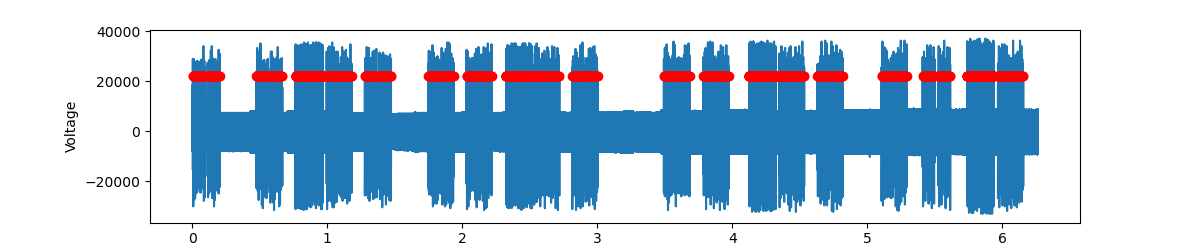

In [19]:
%matplotlib widget
#use of Widget functionality is important here (using it as our "GUI")

# Get the trigger times from the data itself (is there a better way to do this?)
from scipy.signal import find_peaks

# Set some params
thresh_pct = 0.4   # fraction of maximum amplitude to use as threshold for peak detection
stim_chan = 'DC02'  # you may need to explore the DC channels to find which one looks best for a given subject
distance_ = (full_sess_raw.info['sfreq']/50)/2  # to find the minimum distance between peaks, we use 50Hz (during TBS) as the maximum pulse rate, and divide by 2 to give us an error margin. 

# Load the trigger data
raw_traces = full_sess_raw.get_data(picks=[stim_chan])

# Detect stimulation peaks (better to use un-rereferenced data)
trg = raw_traces[0, :]
thresh = thresh_pct*np.nanmax(trg) #take the threshold as % of the max value
pk, _ = find_peaks(trg, height=thresh, distance=distance_)  #find the trigger peaks
print(str(len(pk))+' triggers identified.')

# Plot the triggers
plt.figure(figsize=(12, 2.5));
plt.plot(raw_traces[0, :])
plt.plot(pk, [thresh*1.5]*len(pk), 'ro')
plt.xlabel('Time (samples)'); plt.ylabel('Voltage');

# Plot the triggers -- zoomed in
# plt.figure(figsize=(12, 2.5));
# plt.plot(raw_traces[0, :])
# plt.plot(pk, [thresh*1.5]*len(pk), 'ro')
# plt.xlabel('Time (samples)'); plt.ylabel('Voltage');
# plt.xlim(int(0), int(0.04e6))

**Manually record stim intervals**

There is frequent experimental variability (i.e. needing to change stim sites, interruptions due to clinical care, miscounted iTBS trains, etc.) necessitating a manual look at the data to ensure blocks/steps are annotated correctly. 

Note: following sham iTBS2, it becomes difficult to tell spES at high/low apart

In [6]:
stim_intervals = {'LOFV13-LOFV14': {'BaselineHigh': (1.9e03, 9.8e04),
                                  'BaselineLow': (1.109e05, 2.05e05),
                                  'PreiTBS1High': (4.695e05, 5.642e05),
                                  'PreiTBS1Low': (5.643e05, 6.712e05), 
                                  'iTBS1': (7.602e05, 9.713e05),
                                  'PostiTBS1High': (9.911e05, 1.0867e06), 
                                  'PostiTBS1Low': (1.0868e06, 1.1843e06), 
                                  'PreShamiTBS1High': (1.2740e06, 1.3711e06), 
                                  'PreShamiTBS1Low': (1.3712e06, 1.4742e06), 
                                  'ShamiTBS1': np.nan, 
                                  'PostShamiTBS1High': (1.7434e06, 1.8405e06),
                                  'PostShamiTBS1Low': (1.8406e06, 1.9387e06), 
                                  'PreiTBS2High': (2.0277e06, 2.1233e06), 
                                  'PreiTBS2Low': (2.1234e06, 2.2204e06), 
                                  'iTBS2': (2.3185e06, 2.5207e06), 
                                  'PostiTBS2High': (2.5301e06, 2.6242e06), 
                                  'PostiTBS2Low': (2.6243e06, 2.7233e06),
                                  'PreShamiTBS2High': (2.8110e06, 2.9066e06),
                                  'PreShamiTBS2Low': (2.9067e06, 3.0047e06),
                                  'ShamiTBS2': np.nan,
                                  'PostShamiTBS2High': (3.4883e06, 3.5835e06), 
                                  'PostShamiTBS2Low': (3.5836e06, 3.6890e06), 
                                  'PreiTBS3High': (3.7822e06, 3.8769e06),
                                  'PreiTBS3Low': (3.8770e06, 3.9755e06),
                                  'iTBS3': (4.1200e06, 4.3261e06), 
                                  'PostiTBS3High': (4.3421e06, 4.4387e06), 
                                  'PostiTBS3Low': (4.4388e06, 4.5368e06), 
                                  'PreShamiTBS3High': (4.6275e06, 4.7221e06), 
                                  'PreShamiTBS3Low': (4.7222e06, 4.8234e06), 
                                  'ShamiTBS3': np.nan, 
                                  'PostShamiTBS3High': (5.1014e06, 5.1961e06), 
                                  'PostShamiTBS3Low': (5.1962e06, 5.2957e06), 
                                  'PreiTBS4High': (5.4057e06, 5.5028e06), 
                                  'PreiTBS4Low': (5.5221e06, 5.6163e06), 
                                  'PostiTBS4High': (5.9635e06, 6.0601e06), 
                                  'PostiTBS4Low': (6.0602e06, 6.1582e06)
                                  },
                  'LPLV14-LPLV15': {'iTBS4': (5.7367e06, 5.9374e06)},
                 }


**Interpolate the stim artifact to avoid aliasing artifact when we do filtering steps later**

In [7]:
from codebase import interpolate_stim, signalblender

# Need to redefine the interpolation function with a given set of input variables
def packaged_function(timeseries, triggers=pk, sfreq=full_sess_raw.info['sfreq']):
    return interpolate_stim(timeseries, triggers, sfreq)

# Run scrubbing operation
full_sess_raw = full_sess_raw.apply_function(packaged_function, picks=['seeg', 'eeg'], channel_wise=True)

**Now implement final filtering steps which can be done cleanly**

In [8]:
# Filtering steps: (0) high-pass filter ~0.1-0.5 Hz (done), (1) scrub stim artifact (done),
# (2) Notch, (3) Downsample (built-in low-pass filter), (4) optional: 35Hz low-pass (for ERP-only analysis)

sfreq_ = 500  # downsample to 500Hz
fsr = full_sess_raw.copy().notch_filter(freqs = [60, 120, 180], method='spectrum_fit', verbose=True, n_jobs=-1,)
fsr = fsr.resample(sfreq=sfreq_, verbose=True, n_jobs=-1,)

Filtering raw data in 3 contiguous segments


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:   17.8s
[Parallel(n_jobs=-1)]: Done 212 out of 212 | elapsed:   22.7s finished


Removed notch frequencies (Hz):
     60.00 : 97308 windows
    120.00 : 97308 windows
    180.00 : 97308 windows


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:    7.7s
[Parallel(n_jobs=-1)]: Done 212 out of 212 | elapsed:   10.9s finished


Removed notch frequencies (Hz):
     60.00 : 75684 windows
    120.00 : 75684 windows
    180.00 : 75684 windows


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 212 out of 212 | elapsed:   13.2s finished


Removed notch frequencies (Hz):
     60.00 : 91584 windows
    120.00 : 91584 windows
    180.00 : 91584 windows
Finding events on: CCEP, DC02, DC03, DC04, DC05
Trigger channel CCEP has a non-zero initial value of 65567 (consider using initial_event=True to detect this event)
1486158 events found on stim channel CCEP
Event IDs: [  36262   36629   36995 ... 5227472 5227838 5228205]


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_45303/177816540.py:6: RuntimeWarning: Trigger channel contains negative values, using absolute value. If data were acquired on a Neuromag system with STI016 active, consider using uint_cast=True to work around an acquisition bug
  fsr = fsr.resample(sfreq=sfreq_, verbose=True, n_jobs=-1,)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  72 tasks      | elapsed:    1.4s
/Users/esolomon/anaconda3/envs/mne_development_2025/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done 194 out of 217 | elapsed:    3.6s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done 217 out of 217 | elapsed:    3.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent wor

Finding events on: CCEP, DC02, DC03, DC04, DC05
Trigger channel CCEP has a non-zero initial value of 65567 (consider using initial_event=True to detect this event)
956445 events found on stim channel CCEP
Event IDs: [  49083   49449   49450 ... 5227472 5227838 5228205]


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_45303/177816540.py:6: RuntimeWarning: Trigger channel contains negative values, using absolute value. If data were acquired on a Neuromag system with STI016 active, consider using uint_cast=True to work around an acquisition bug
  fsr = fsr.resample(sfreq=sfreq_, verbose=True, n_jobs=-1,)


**Assign metadata to allow easy selection of particular "steps" in the experiment. Note that this may require frequent manual intervention on a subject-to-subject basis if there are differences in how each subject was run.**

In [9]:
# Need to adjust the peak times since we've downsampled
native_sampling = full_sess_raw.info['sfreq']
dsample = int(native_sampling/sfreq_)

# Construct a metadata DataFrame
metadata = pd.DataFrame()
for stim_chan in stim_intervals: 
    for k, v in stim_intervals[stim_chan].items():
        if stim_intervals[stim_chan][k] is np.nan:
            continue
        else:
            pass
        if ('High' in k):  # may need to modify if we end up with multiple sessions of TBS
            stim_intensity = 7
        else:
            stim_intensity = 4
        interval_peaks = pk[(pk>stim_intervals[stim_chan][k][0]) & (pk<stim_intervals[stim_chan][k][1])]
        for pidx, peak_sample in enumerate(interval_peaks):
            mydict = {'sample': int(peak_sample/dsample), 'sample_raw': peak_sample, 'block': k, 'pulse_within_step': pidx, 
                      'stim_intensity': stim_intensity, 'stim_target': stim_chan}
            metadata = pd.concat([metadata, pd.DataFrame(mydict, index=[0])], ignore_index=True)

**Create epochs around each discrete event**

Typically most useful for CCEPs

In [10]:
# Define an event dictionary for all discrete event types
event_dict = {'pulse': 1}

# Construct events array
events = np.zeros([len(metadata), 3])
events[:, 0] = metadata['sample']
events[:, 2] = 1

# Create Epochs object, including a rejection parameter to discard epochs with high peak-to-peak shifts
epochs_trigger = mne.Epochs(fsr, events.astype(int), event_id=event_dict, metadata=metadata,
                            tmin=-1, tmax=2.3, baseline=(-1, -0.1), reject_by_annotation=False, detrend=1, 
                           reject=None)

Adding metadata with 6 columns
3240 matching events found
Applying baseline correction (mode: mean)
0 projection items activated


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_45303/3611445352.py:10: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.Epochs(fsr, events.astype(int), event_id=event_dict, metadata=metadata,


**Create DataFrame for storing channel labels and identifying bad electrodes**

An additional filter is applied later on in analysis to remove the full set of bad electrodes. 

In [11]:
# Load CSV file
loc = pd.read_csv('../data/S24_236/S24_236_loc.csv')

# Identify bad channels (this varies depending on what data is available in the CSV file -- ideally, check for Josef's labels,
# but if those are not available, look for atlas locations of "Unknown" or "undefined" (liable to be out-of-brain but not 100% perfect). 

# Check CSV files for manual lables from Josef, which take many different forms
jp_col_labels = ['JP_label_std', 'Josef Label STD', 'Josef Label Std', 'JOSEF', 'JP_label', 'Josef Labeling', 'JOSEF ANATOMY', 'Josef Anatomy', 'JOSEF Labels STD', 'JOSEF LABELS std']
jp_labels = []
for col_label in jp_col_labels:
    try:
        jp_labels = loc[col_label].astype(str)
        break
    except:
        continue
if len(jp_labels)==0:
    print('No JP column found! Using alternative labels to identify bad electrodes.')
    bads = loc[loc['FS_vol'].astype(str).str.contains('Unknown')]
else:
    bads = loc[jp_labels.str.contains('exclude', case=False)]

# Identify channel pairs where at least one monopolar is identified as bad
bads_label = np.array(bads['FS_label'].str.lower())
bp_to_exclude = []
for e in epochs_trigger.ch_names:
    s = e.lower(); s = s.split('-')
    if len(s) == 1:
        continue  #not an iEEG channel
    if (s[0] in bads_label) or (s[1] in bads_label):
        bp_to_exclude.append(e)

# Set bad channels
epochs_trigger.info['bads'] = bp_to_exclude
                

No JP column found! Using alternative labels to identify bad electrodes.


**Finally, save completed output**

Note that the localization CSV file is still saved separately, but event metadata is included in the output .fif file.

In [14]:
epochs_trigger.save('../derivatives/pulse_labels/'+subject+'_trigs-epo.fif', overwrite=True)
fsr.save('../derivatives/pulse_labels/'+subject+'_unepoched_eeg.fif', overwrite=True)

Overwriting existing file.
Splitting into 3 parts
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Writing /Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S24_236_unepoched_eeg.fif
Overwriting existing file.
Closing /Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S24_236_unepoched_eeg.fif
Overwriting existing file.
Writing /Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S24_236_unepoched_eeg-1.fif
Overwriting existing file.
Closing /Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S24_236_unepoched_eeg-1.fif
[done]


[PosixPath('/Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S24_236_unepoched_eeg.fif'),
 PosixPath('/Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S24_236_unepoched_eeg-1.fif')]

Setting up low-pass filter at 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 221 samples (0.442 s)



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 360 tasks      | elapsed:    0.7s


Need more than one channel to make topography for seeg. Disabling interactivity.


[Parallel(n_jobs=-1)]: Done 3576 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 5196 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 5724 out of 5724 | elapsed:    1.0s finished


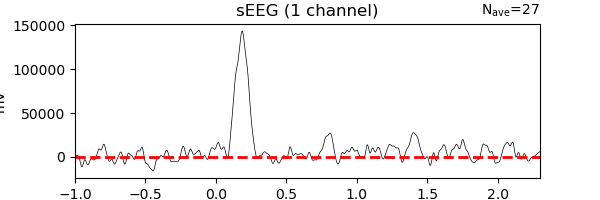

In [31]:
# Exclude the stimulated lead/channel due to excessive artifact
#stim_lead = [c for c in epochs_trigger.ch_names if 'LPRS' in c]

# Create an evoked object and low-pass filter for ERP analysis
stim_channel = 'LVOF13-LVOF14'
sense_channel = 'LPLV14-LPLV15'
evoked = epochs_trigger['(block=="PreiTBS3Low") & (stim_target=="'+stim_channel+'")'].load_data().filter(h_freq=30, l_freq=None, n_jobs=-1).average()

# Plot CCEPs from desired electrodes
picks_ = [e for e in evoked.ch_names if sense_channel in e]
fig = plt.figure(figsize=(6, 2)); ax=plt.subplot(111)
evoked.plot(picks=picks_, xlim=(-1, 2.3), hline=[0], axes=ax);
ax.vlines([0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='k')
#fig.savefig('./figs/LPLV7-LPLV8_CCEP_example_step21.pdf')

**Plot example trials**

(-0.3, 2.3)

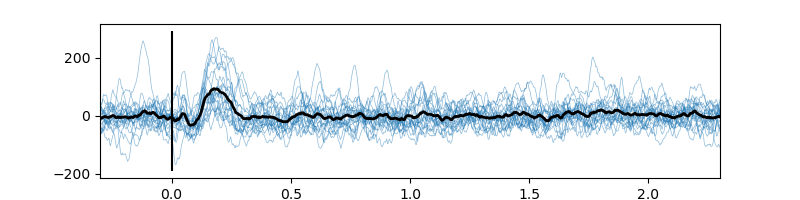

In [36]:
%matplotlib widget
eeg = epochs_trigger['(block=="PostiTBS1High") & (stim_target=="'+stim_channel+'")'].load_data()  #.crop(tmin=-1, tmax=2.3)
cidx = epochs_trigger.ch_names.index(sense_channel)
eeg = eeg.get_data()[:, cidx, :]

from scipy.stats import zscore
eeg_z = zscore(eeg, axis=None)  # Zscore across pooled variance over all trials and timepoints
bad_epochs = np.unique(np.where(np.abs(eeg_z)>5)[0])  # identify bad epochs
eeg[bad_epochs, :] = np.nan  # NaN out bad epochs

plt.figure(figsize=(8, 2)); ax=plt.subplot(111)
plt.plot(np.arange(eeg.shape[-1])/epochs_trigger.info['sfreq']-1, eeg[:, :].T, linewidth=0.5, alpha=0.5, color='C0');
plt.plot(np.arange(eeg.shape[-1])/epochs_trigger.info['sfreq']-1, np.nanmean(eeg[0:, :], 0)*1, linewidth=2, color='k')
plt.vlines([0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='k')
plt.xlim(-0.3, 2.3)

#### Drill down to individual electrode/region

In [37]:
from codebase import channel_lookup

#Selec desired channel(s) for stim/sense
picks_ = channel_lookup(loc, 'Right-Amyg', epochs_trigger.ch_names, column='FS_vol')
picks_ = [p for p in picks_ if p not in bp_to_exclude]
print('Channels Used:' + str(picks_))

picks_ = [sense_channel]

Channels Used:[]


In [38]:
from mne.time_frequency import tfr_morlet

# Set parameters
freqs_ = np.logspace(start=np.log10(2), stop=np.log10(100), num=40)
n_cycles_ = 2 + 1.5*np.log(freqs_)
tbs_mode = 'iTBS1High'

# Create a new data object for channels/region in question
roi_epo = epochs_trigger.load_data().copy().pick_channels(picks_,)

# Aggregate bad epochs to drop in these blocks/channels
indices_to_drop = []
for b in ['Pre'+tbs_mode, 'Post'+tbs_mode, 'BaselineHigh']:
    for c in picks_:
        indices_to_drop.extend(list(bad_epochs_dict['global_index'][stim_channel][b][c]))
roi_epo.drop(indices_to_drop)

# Let's look at pre/post TBS power
power_pre, itc_pre = tfr_morlet(roi_epo['(block=="Pre'+tbs_mode+'") & (stim_target=="'+stim_channel+'")'],     
                        freqs=freqs_, n_cycles=n_cycles_, return_itc=True, n_jobs=-1)

power_post, itc_post = tfr_morlet(roi_epo['(block=="Post'+tbs_mode+'") & (stim_target=="'+stim_channel+'")'],
                        freqs=freqs_, n_cycles=n_cycles_, return_itc=True, n_jobs=-1)

power_base, itc_base = tfr_morlet(roi_epo['(block=="BaselineHigh") & (stim_target=="'+stim_channel+'")'],
                        freqs=freqs_, n_cycles=n_cycles_, return_itc=True, n_jobs=-1)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Dropped 3 epochs: 23, 25, 716
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


**Plot before TBS**

Applying baseline correction (mode: zscore)


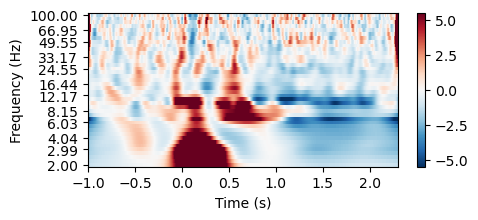

Applying baseline correction (mode: zscore)


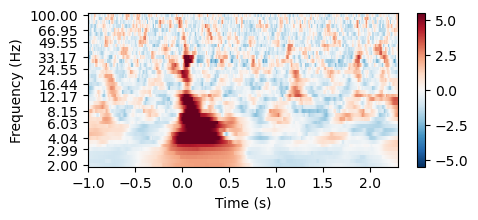

Applying baseline correction (mode: zscore)
Applying baseline correction (mode: zscore)


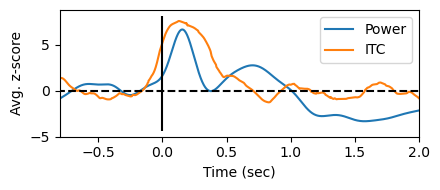

In [40]:
%matplotlib inline

#fig, axes = plt.subplots(nrows=1, ncols=1);
plt.figure(figsize=(5, 2)); ax=plt.subplot(111)
im = power_pre.plot(picks=picks_, tmin=-1.0, tmax=2.3, 
           baseline=(-0.9, -0.1), mode='zscore', combine='mean', vlim=(-5.5, 5.5), axes=ax)
#fig.savefig('./figs/LPLV7_before_TBS4_TFR.png', dpi=300)

plt.figure(figsize=(5, 2)); ax=plt.subplot(111)
itc_pre.plot(picks=picks_, tmin=-1.0, tmax=2.3, 
        baseline=(-0.9, -0.1), mode='zscore', combine='mean', vlim=(-5.5, 5.5), axes=ax)

# Plot 3Hz power/ITC
fmin = 4; fmax = 8
dp_pre = power_pre.copy().apply_baseline((-0.9, -0.1), mode='zscore').get_data(fmin=fmin, fmax=fmax, picks=picks_);
di_pre = itc_pre.copy().apply_baseline((-0.9, -0.1), mode='zscore').get_data(fmin=fmin, fmax=fmax, picks=picks_);
plt.figure(figsize=(4.5, 2)); ax=plt.subplot(111);
X = np.arange(dp_pre.shape[-1])/power_pre.info['sfreq']-1
plt.plot(X, np.mean(np.mean(dp_pre, 1), 0), label='Power'); plt.plot(X, np.mean(np.mean(di_pre, 1), 0), label='ITC');
plt.vlines([0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='k')
plt.hlines([0], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='k', linestyles='--')
plt.xlim(-0.8, 2.0)
plt.xlabel('Time (sec)'); plt.ylabel('Avg. z-score'); plt.legend()
plt.tight_layout()

**Plot after TBS**

Applying baseline correction (mode: zscore)


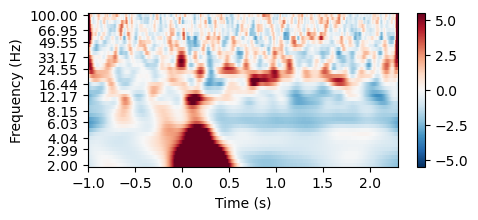

Applying baseline correction (mode: zscore)


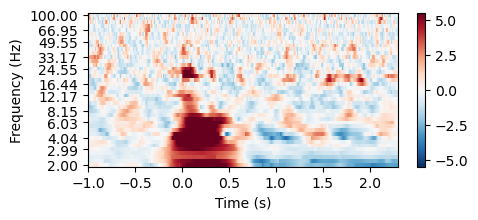

Applying baseline correction (mode: zscore)
Applying baseline correction (mode: zscore)


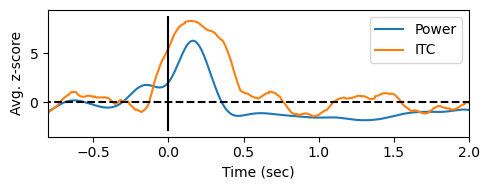

In [41]:
#fig, axes = plt.subplots(nrows=1, ncols=1);
plt.figure(figsize=(5, 2)); ax=plt.subplot(111)
power_post.plot(picks=picks_, tmin=-1.0, tmax=2.3, 
           baseline=(-0.9, -0.1), mode='zscore', combine='mean', vlim=(-5.5, 5.5), axes=ax)
#plt.vlines([0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='k', linestyle='--')
#fig.savefig('./figs/LPLV7_before_TBS4_TFR.png', dpi=300)

plt.figure(figsize=(5, 2)); ax=plt.subplot(111)
itc_post.plot(picks=picks_, tmin=-1.0, tmax=2.3, 
        baseline=(-0.9, -0.1), mode='zscore', combine='mean', vlim=(-5.5, 5.5), axes=ax)

# Plot 3Hz power/ITC
fmin = 4; fmax = 8
dp_post = power_post.copy().apply_baseline((-0.9, -0.1), mode='zscore').get_data(fmin=fmin, fmax=fmax, picks=picks_);
di_post = itc_post.copy().apply_baseline((-0.9, -0.1), mode='zscore').get_data(fmin=fmin, fmax=fmax, picks=picks_);
plt.figure(figsize=(5, 2)); ax=plt.subplot(111);
X = np.arange(dp_post.shape[-1])/power_pre.info['sfreq']-1
plt.plot(X, np.mean(np.mean(dp_post, 1), 0), label='Power'); plt.plot(X, np.mean(np.mean(di_post, 1), 0), label='ITC');
plt.vlines([0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='k')
plt.hlines([0], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='k', linestyles='--')
plt.xlim(-0.8, 2.0)
plt.xlabel('Time (sec)'); plt.ylabel('Avg. z-score'); plt.legend()
plt.tight_layout()

**Plot baseline**

Applying baseline correction (mode: zscore)


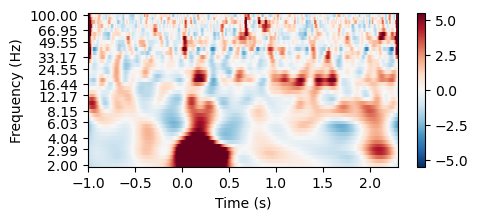

Applying baseline correction (mode: zscore)


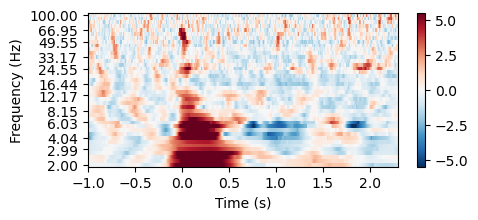

Applying baseline correction (mode: zscore)
Applying baseline correction (mode: zscore)


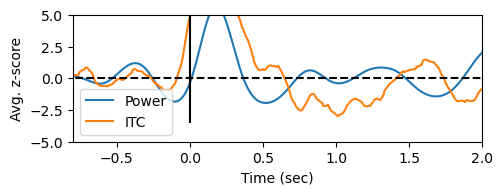

In [42]:
#fig, axes = plt.subplots(nrows=1, ncols=1);
plt.figure(figsize=(5, 2)); ax=plt.subplot(111)
power_base.plot(picks=picks_, tmin=-1.0, tmax=2.3, 
           baseline=(-0.9, -0.1), mode='zscore', combine='mean', vlim=(-5.5, 5.5), axes=ax)
#fig.savefig('./figs/LPLV7_before_TBS4_TFR.png', dpi=300)

plt.figure(figsize=(5, 2)); ax=plt.subplot(111)
itc_base.plot(picks=picks_, tmin=-1.0, tmax=2.3, 
        baseline=(-0.9, -0.1), mode='zscore', combine='mean', vlim=(-5.5, 5.5), axes=ax)

# Plot 3Hz power/ITC
fmin = 4; fmax = 8
dp_base = power_base.copy().apply_baseline((-0.9, -0.1), mode='zscore').get_data(fmin=fmin, fmax=fmax, picks=picks_)
di_base = itc_base.copy().apply_baseline((-0.9, -0.1), mode='zscore').get_data(fmin=fmin, fmax=fmax, picks=picks_)
plt.figure(figsize=(5, 2)); ax=plt.subplot(111);
X = np.arange(dp_base.shape[-1])/power_pre.info['sfreq']-1
plt.plot(X, np.mean(np.mean(dp_base, 1), 0), label='Power'); plt.plot(X, np.mean(np.mean(di_base, 1), 0), label='ITC');
plt.vlines([0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='k')
plt.hlines([0], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='k', linestyles='--')
plt.xlim(-0.8, 2.0)
plt.xlabel('Time (sec)'); plt.ylabel('Avg. z-score'); plt.legend()
plt.ylim(-5, 5)
plt.tight_layout()

##### Plot power/ITC for each period together

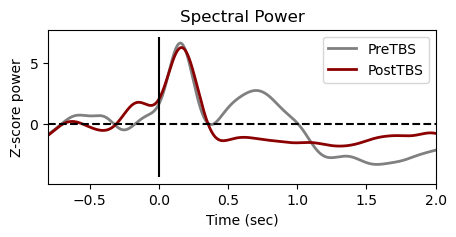

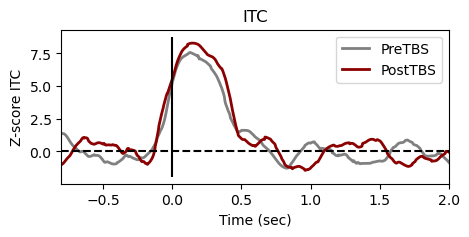

In [43]:
# First do power
plt.figure(figsize=(5, 2)); ax=plt.subplot(111);
X = np.arange(dp_base.shape[-1])/power_pre.info['sfreq']-1
plt.plot(X, np.mean(np.mean(dp_pre, 1), 0), label='PreTBS', color='gray', linewidth=2)
plt.plot(X, np.mean(np.mean(dp_post, 1), 0), label='PostTBS', color='darkred', linewidth=2)
plt.xlim(-0.8, 2.0); #plt.ylim(-5, 5)
plt.vlines([0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='k')
plt.hlines([0], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='k', linestyles='--')
plt.title('Spectral Power'); plt.ylabel('Z-score power'); plt.xlabel('Time (sec)')
plt.legend()

# Now do ITC
plt.figure(figsize=(5, 2)); ax=plt.subplot(111);
X = np.arange(di_base.shape[-1])/power_pre.info['sfreq']-1
plt.plot(X, np.mean(np.mean(di_pre, 1), 0), label='PreTBS', color='gray', linewidth=2)
plt.plot(X, np.mean(np.mean(di_post, 1), 0), label='PostTBS', color='darkred', linewidth=2)
plt.xlim(-0.8, 2.0); #plt.ylim(-5, 5)
plt.vlines([0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='k')
plt.hlines([0], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='k', linestyles='--')
plt.title('ITC'); plt.ylabel('Z-score ITC'); plt.xlabel('Time (sec)')
plt.legend()

**Now do Welch's method**

Measure theta power before/after each TBS block and plot changes over time

In [43]:
from mne.time_frequency import psd_array_welch

# Set some params; default should be t_start=0.6, window_size=0.5, baseline_start=0.1, freqs=(4, 8)
t_start = 0.6
window_size = 0.8
baseline_start = -0.1
baseline_win = window_size
freq_range = (4, 8)
stim_target = 'LANT7-LANT8'
intensity = 'Low'

# Raw values dictionary for later analysis
raw_dict = {}

# Need to exclude bad channels, but using a non-MNE object, so must get indices for channels
bad_chan_idxs = [epochs_trigger.ch_names.index(i) for i in bp_to_exclude]

# Loop through blocks of the experiment
for blk in ['(block=="PreiTBS1'+intensity+'")', '(block=="PostiTBS1'+intensity+'")',
            '(block=="PreiTBS2'+intensity+'")','(block=="PostiTBS2'+intensity+'")',
           '(block=="PreShamiTBS1'+intensity+'")', '(block=="PostShamiTBS1'+intensity+'")',
           '(block=="PreiTBS3'+intensity+'")', '(block=="PostiTBS3'+intensity+'")',
           '(block=="PreiTBS4'+intensity+'")', '(block=="PostiTBS4'+intensity+'")']:

    d = epochs_trigger[blk+' & (stim_target=="'+stim_target+'")'].crop(tmin=t_start, tmax=t_start+window_size).get_data()
    spec_post, freqs = psd_array_welch(d, epochs_trigger.info['sfreq'], fmin=freq_range[0], fmax=freq_range[1], average='mean',
                                n_jobs=-1, verbose=False)
    d_base = epochs_trigger[blk+' & (stim_target=="'+stim_target+'")'].crop(tmin=baseline_start-baseline_win, tmax=baseline_start).get_data()
    spec_baseline, freqs = psd_array_welch(d_base, epochs_trigger.info['sfreq'], fmin=freq_range[0], fmax=freq_range[1], average='mean',
                                n_jobs=-1, verbose=False)

    # Log-transform and average over frequencies
    data_post = np.mean(np.log10(spec_post), 2)
    data_base = np.mean(np.log10(spec_baseline), 2)
    data_corr_TBS = data_post-data_base  # Baseline correct

    # NaN out bad epochs
    for cidx, c in enumerate(epochs_trigger.ch_names):
        data_corr_TBS[bad_epochs_dict['within_block'][stim_target][blk.split('"')[-2]][c], cidx] = np.nan

    # NaN out bad channels
    data_corr_TBS[:, bad_chan_idxs] = np.nan  # identified via localization structure
    stim_lead = [idx for idx, c in enumerate(epochs_trigger.ch_names) if (stim_target[:4] in c)]
    data_corr_TBS[:, stim_lead] = np.nan # contacts in the stimulation lead
    
    # Save results in dictionary
    raw_dict[blk] = data_corr_TBS


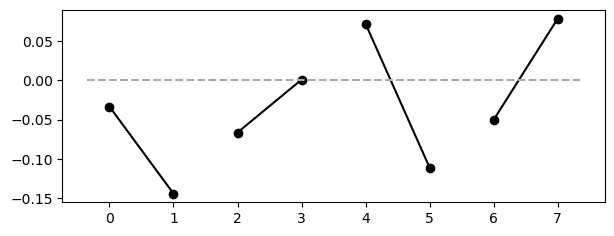

In [706]:
# Plot results 
plt.figure(figsize=(7, 2.5)); ax=plt.subplot(111)

# Specify a channel to look at
chanidx = 17 #[idx for idx, e in enumerate(spec_post.ch_names) if 'LPOB' in e]

plt.plot([0, 1], [np.mean(all_pre[0][:, chanidx]), np.mean(all_post[0][:, chanidx])], 
         color='k', linestyle='-', marker='o')
plt.plot([2, 3], [np.mean(all_pre[1][:, chanidx]), np.mean(all_post[1][:, chanidx])], 
         color='k', linestyle='-', marker='o')
plt.plot([4, 5], [np.mean(all_pre[2][:, chanidx]), np.mean(all_post[2][:, chanidx])], 
         color='k', linestyle='-', marker='o')
plt.plot([6, 7], [np.mean(all_pre[3][:, chanidx]), np.mean(all_post[3][:, chanidx])], 
         color='k', linestyle='-', marker='o')
plt.hlines([0], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], linestyle='--', color='darkgray')
plt.savefig('./figs/LINS11-12_TBS_deltas.pdf')

#### Loop over channels and summarize the effect of cTBS, iTBS on each

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_24845/3079027390.py:9: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  t, p = ttest_1samp(raw_dict[block], 0, axis=0, nan_policy='omit')
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_24845/3079027390.py:18: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  t, p = ttest_1samp(raw_dict[block], 0, axis=0, nan_policy='omit')
/Users/esolomon/anaconda3/envs/mne_development_2025/lib/python3.10/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will b

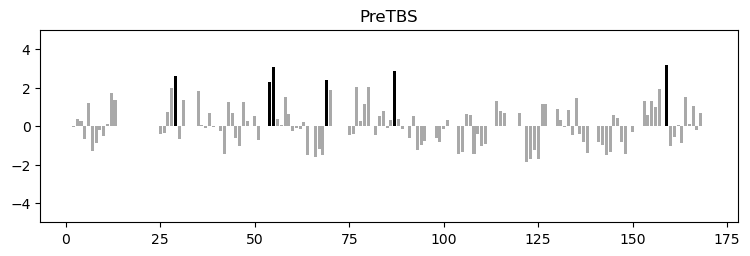

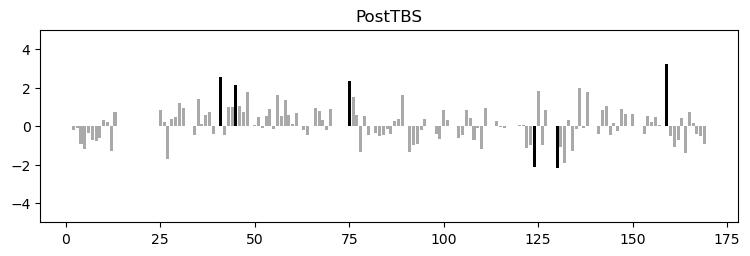

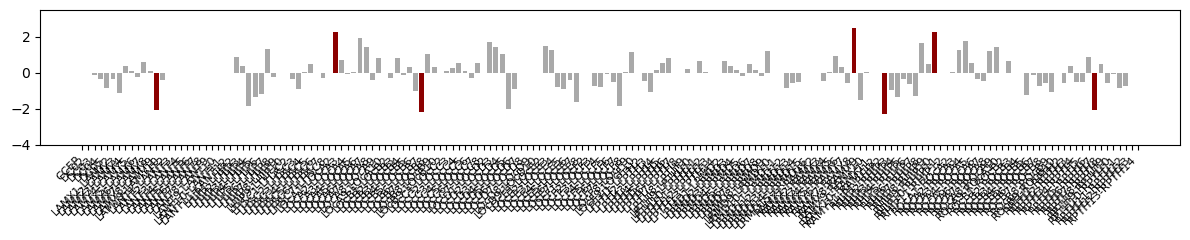

In [52]:
from scipy.stats import ttest_1samp, ttest_rel, ttest_ind
%matplotlib inline

condition = 'iTBS2Low'

# Plot results
block = '(block=="Pre'+condition+'")'
fig = plt.figure(figsize=(9, 2.5))
t, p = ttest_1samp(raw_dict[block], 0, axis=0, nan_policy='omit')
n = np.ones(len(t)); n[p>0.05] = np.nan
plt.bar(np.arange(len(t)), t, color='darkgray')
plt.bar(np.arange(len(t)), t*n, color='black') 
plt.ylim(-5, 5)
plt.title('PreTBS')

fig = plt.figure(figsize=(9, 2.5))
block = '(block=="Post'+condition+'")'
t, p = ttest_1samp(raw_dict[block], 0, axis=0, nan_policy='omit')
n = np.ones(len(t)); n[p>0.05] = np.nan
plt.bar(np.arange(len(t)), t, color='darkgray')
plt.bar(np.arange(len(t)), t*n, color='black') 
plt.ylim(-5, 5)
plt.title('PostTBS')

fig = plt.figure(figsize=(12, 2.5))
t, p = ttest_ind(raw_dict['(block=="Post'+condition+'")'], raw_dict['(block=="Pre'+condition+'")'], axis=0, nan_policy='omit')
n = np.ones(len(t)); n[p>0.05] = np.nan
plt.bar(np.arange(len(t)), t, color='darkgray')
plt.bar(np.arange(len(t)), t*n, color='darkred') 
plt.ylim(-4, 3.5)
plt.xticks(ticks=np.arange(len(epochs_trigger.ch_names)), labels=epochs_trigger.ch_names, fontsize=8, rotation=45, ha='right');
plt.tight_layout()
#plt.savefig('./figs/TBS4_skyline.pdf')


In [51]:
# Identify significant channels
cidxs = np.where(p<0.01)[0]
print(np.array(epochs_trigger.ch_names)[cidxs])

[]


#### Electrode distance-based analysis

In [53]:
def get_elec_dists(loc, chan_name,):
    import numpy as np
    import pandas as pd
    
    # Break down to monopolars for table lookup
    an = chan_name.split('-')[0]
    cath = chan_name.split('-')[1]
    
    # Get average of both monopolars to define a center for the radius
    an_data = loc[loc['FS_label']==an]
    cath_data = loc[loc['FS_label']==cath]
    avg_center = np.mean(np.array([an_data[['MNI_coord_1', 'MNI_coord_2', 'MNI_coord_3']], cath_data[['MNI_coord_1', 'MNI_coord_2', 'MNI_coord_3']] ]), 0)
    
    # Calculate distance to all other contacts
    elec_dists = []
    for i in range(len(loc)):
        mni_coords = np.array(loc.iloc[i][['MNI_coord_1', 'MNI_coord_2', 'MNI_coord_3']])
        dist = np.linalg.norm(avg_center-mni_coords)
        elec_dists.append(dist)

    # Note: returns locations in order of channels provided in localization structure, not MNE ch_names object. 
    return np.array(elec_dists)
    

In [54]:
elec_dists = get_elec_dists(loc, stim_target)
nearest_elecs = loc.iloc[elec_dists<20]
nearest_elec_names = list(nearest_elecs['FS_label'])
nearest_elec_idxs = [idx for idx, n in enumerate(epochs_trigger.ch_names) if ('-' in n) and ((n.split('-')[0] in nearest_elec_names) or (n.split('-')[1] in nearest_elec_names))]

# Calculate t-values
t, p = ttest_ind(raw_dict['(block=="Post'+condition+'")'], raw_dict['(block=="Pre'+condition+'")'], axis=0, nan_policy='omit')

# Get t-stat for nearest elecs
print(t[nearest_elec_idxs])
print(np.array(epochs_trigger.ch_names)[nearest_elec_idxs])

[ 0.10399418 -0.23954278         nan         nan         nan         nan
         nan         nan         nan         nan         nan -0.19343896
  1.21788254         nan         nan -0.84316848]
['LAMY4-LAMY5' 'LAMY5-LAMY6' 'LANT3-LANT4' 'LANT4-LANT5' 'LANT5-LANT6'
 'LANT6-LANT7' 'LANT7-LANT8' 'LANT8-LANT9' 'LANT9-LANT10' 'LANT10-LANT11'
 'LANT11-LANT12' 'LRMD7-LRMD8' 'LRMD8-LRMD9' 'LRMD9-LRMD10'
 'LRMD10-LRMD11' 'LRMD11-LRMD12']


/Users/esolomon/anaconda3/envs/mne_development_2025/lib/python3.10/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


<BarContainer object of 4 artists>

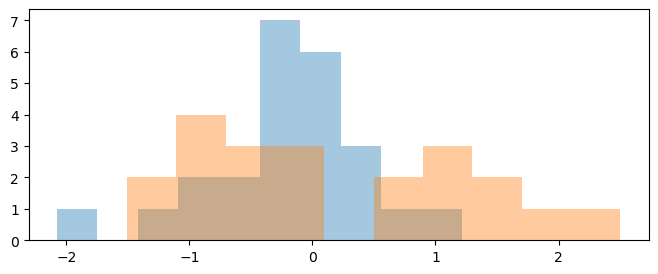

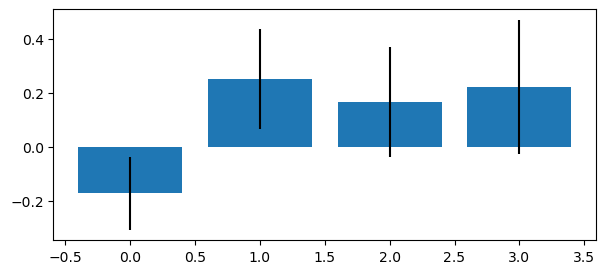

In [55]:
from scipy.stats import sem

# Break up distances into quartiles
quartiles = np.quantile(elec_dists[np.isfinite(elec_dists)], [0.25, 0.5, 0.75])
q1 = quartiles[0]; q2 = quartiles[1]; q3 = quartiles[2]

# First quartile
q_elecs = loc.iloc[elec_dists<q1]
q_elec_names = list(q_elecs['FS_label'])
q_elec_idxs = [idx for idx, n in enumerate(epochs_trigger.ch_names) if ('-' in n) and ((n.split('-')[0] in q_elec_names) or (n.split('-')[1] in q_elec_names))]
q1_ts = t[q_elec_idxs]

# Second quartile
q_elecs = loc.iloc[(elec_dists>q1) & (elec_dists<q2)]
q_elec_names = list(q_elecs['FS_label'])
q_elec_idxs = [idx for idx, n in enumerate(epochs_trigger.ch_names) if ('-' in n) and ((n.split('-')[0] in q_elec_names) or (n.split('-')[1] in q_elec_names))]
q2_ts = t[q_elec_idxs]

# Third quartile
q_elecs = loc.iloc[(elec_dists>q2) & (elec_dists<q3)]
q_elec_names = list(q_elecs['FS_label'])
q_elec_idxs = [idx for idx, n in enumerate(epochs_trigger.ch_names) if ('-' in n) and ((n.split('-')[0] in q_elec_names) or (n.split('-')[1] in q_elec_names))]
q3_ts = t[q_elec_idxs]

# Fourth quartile
q_elecs = loc.iloc[(elec_dists>q3)]
q_elec_names = list(q_elecs['FS_label'])
q_elec_idxs = [idx for idx, n in enumerate(epochs_trigger.ch_names) if ('-' in n) and ((n.split('-')[0] in q_elec_names) or (n.split('-')[1] in q_elec_names))]
q4_ts = t[q_elec_idxs]

#Plot results
plt.figure(figsize=(8, 3)); ax=plt.subplot(111)
plt.hist(q1_ts, alpha=0.4)
#plt.hist(q2_ts, alpha=0.4)
#plt.hist(q3_ts, alpha=0.4)
plt.hist(q4_ts, alpha=0.4)

plt.figure(figsize=(7, 3)); ax=plt.subplot(111)
plt.bar(x=range(4), height=[np.nanmean(q1_ts), np.nanmean(q2_ts), np.nanmean(q3_ts), np.nanmean(q4_ts)], 
       yerr=[sem(q1_ts, nan_policy='omit'), sem(q2_ts, nan_policy='omit'), sem(q3_ts, nan_policy='omit'), sem(q4_ts, nan_policy='omit')])

**Correlate TBS-related patterns between TBS sessions**

<Axes: >

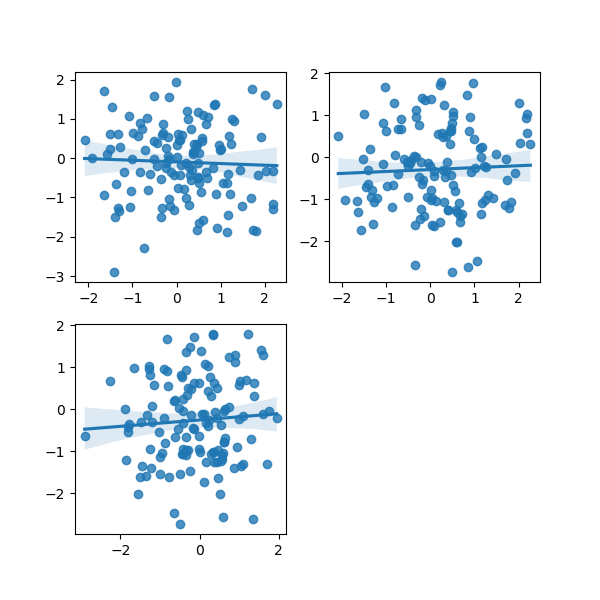

In [294]:
import seaborn as sns

mydict = {}
for condition in ['iTBS1High', 'iTBS2High', 'iTBS3High', 'iTBS4High']:
    t, p = ttest_ind(raw_dict['(block=="Post'+condition+'")'], raw_dict['(block=="Pre'+condition+'")'], axis=0, nan_policy='omit')

    # Remove outliers (rare at this point)
    t[np.abs(t)>10] = np.nan
    
    mydict[condition] = t

plt.figure(figsize=(6, 6)); ax=plt.subplot(221)
sns.regplot(x=mydict['iTBS2High'], y=mydict['iTBS3High'],)
ax=plt.subplot(222)
sns.regplot(x=mydict['iTBS2High'], y=mydict['iTBS4High'])
ax=plt.subplot(223)
sns.regplot(x=mydict['iTBS3High'], y=mydict['iTBS4High'],)